# flow validation points

Scatter of the cosmological parameters used as held-out mock observations for the posterior coverage
test (`run_inference.py --sample_posterior`). The selection is fully deterministic -- see
`msi.utils.coverage._held_out_split` / `sample_coverage_posteriors` -- so this reproduces it directly
in numpy without loading a trained flow checkpoint.

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from trianglechain import TriangleChain

from msfm.utils.input_output import read_yaml
from msi.utils import flow as flow_utils
from msi.apps.run_inference import _load_configs

## paths

In [9]:
out_dir = "/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined"
model_name = "v26"
n_steps = None  # auto-detects the largest preds_*.h5 if omitted

flow_config = (
    "/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined/v26/"
    "v5_runs/v5_maf_wd_maf_likelihood_flow_1000000/flow_config.yaml"
)

## load predictions + configs

In [10]:
pred_dir, pred_file, n_steps = flow_utils.resolve_pred_file(out_dir, model_name, n_steps)
dlss_conf, msfm_conf = _load_configs(pred_dir, None, None)
params = dlss_conf["dset"]["training"]["params"]

grid_preds, grid_cosmos, obs_pred_dict, obs_cosmo_dict, i_signal, i_sobol = flow_utils.load_grid_summaries(pred_file)
print(f"{grid_cosmos.shape[0]} held-out grid points; params = {params}")

Auto-detected n_steps=1000000
Loading predictions from: /users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined/v26/preds_1000000.h5
26-06-19 10:57:45 input_output INF   Loading predictions from /users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined/v26/preds_1000000.h5 
26-06-19 10:57:45 input_output INF   grid_preds.shape = (200000, 20) 
26-06-19 10:57:45 input_output INF   grid_cosmos.shape = (200000, 10) 
26-06-19 10:57:45 input_output INF   DESy3 with shape (20,) 
26-06-19 10:57:45 input_output INF   DESy3_no_psi_rot with shape (20,) 
26-06-19 10:57:45 input_output INF   DESy3_no_sys with shape (20,) 
26-06-19 10:57:45 input_output INF   DESy3_no_sys_no_psi_rot with shape (20,) 
26-06-19 10:57:45 input_output INF   fiducial_bench_mean with shape (20,) 
26-06-19 10:57:45 input_output INF   fiducial_bench_stack with shape (80, 20) 
26-06-19 10:57:45 input_output INF   grid_(1,64,0) with shape (20,) 
26-06-19 10:57:45 input_output INF   grid_(2,64,0) with sha

## reproduce the coverage-test mock selection

Mirrors `coverage.py:_held_out_split` (signal-grouped, deterministic vali split) and the `n_obs`
stride-thinning in `sample_coverage_posteriors` -- same logic, no torch/flow checkpoint required.

In [11]:
flow_conf = read_yaml(flow_config)
vali_split = flow_conf.get("training", {}).get("vali_split", 0.1)
n_obs = flow_conf.get("diagnostics", {}).get("n_obs", 1000)

unique_ids = np.unique(i_signal)
split = int((1 - vali_split) * len(unique_ids))
vali_idx = np.where(np.isin(i_signal, unique_ids[split:]))[0]

theta_vali = grid_cosmos[vali_idx]
n_cosmos = theta_vali.shape[0]
theta_true = theta_vali[:: n_cosmos // n_obs][:n_obs]
print(
    f"{theta_true.shape[0]} mock cosmologies used for posterior coverage "
    f"(of {n_cosmos} held-out validation / {grid_cosmos.shape[0]} total grid points)"
)

1000 mock cosmologies used for posterior coverage (of 25000 held-out validation / 200000 total grid points)


## scatter

100%|██████████| 45/45 [00:00<00:00, 810.48it/s]


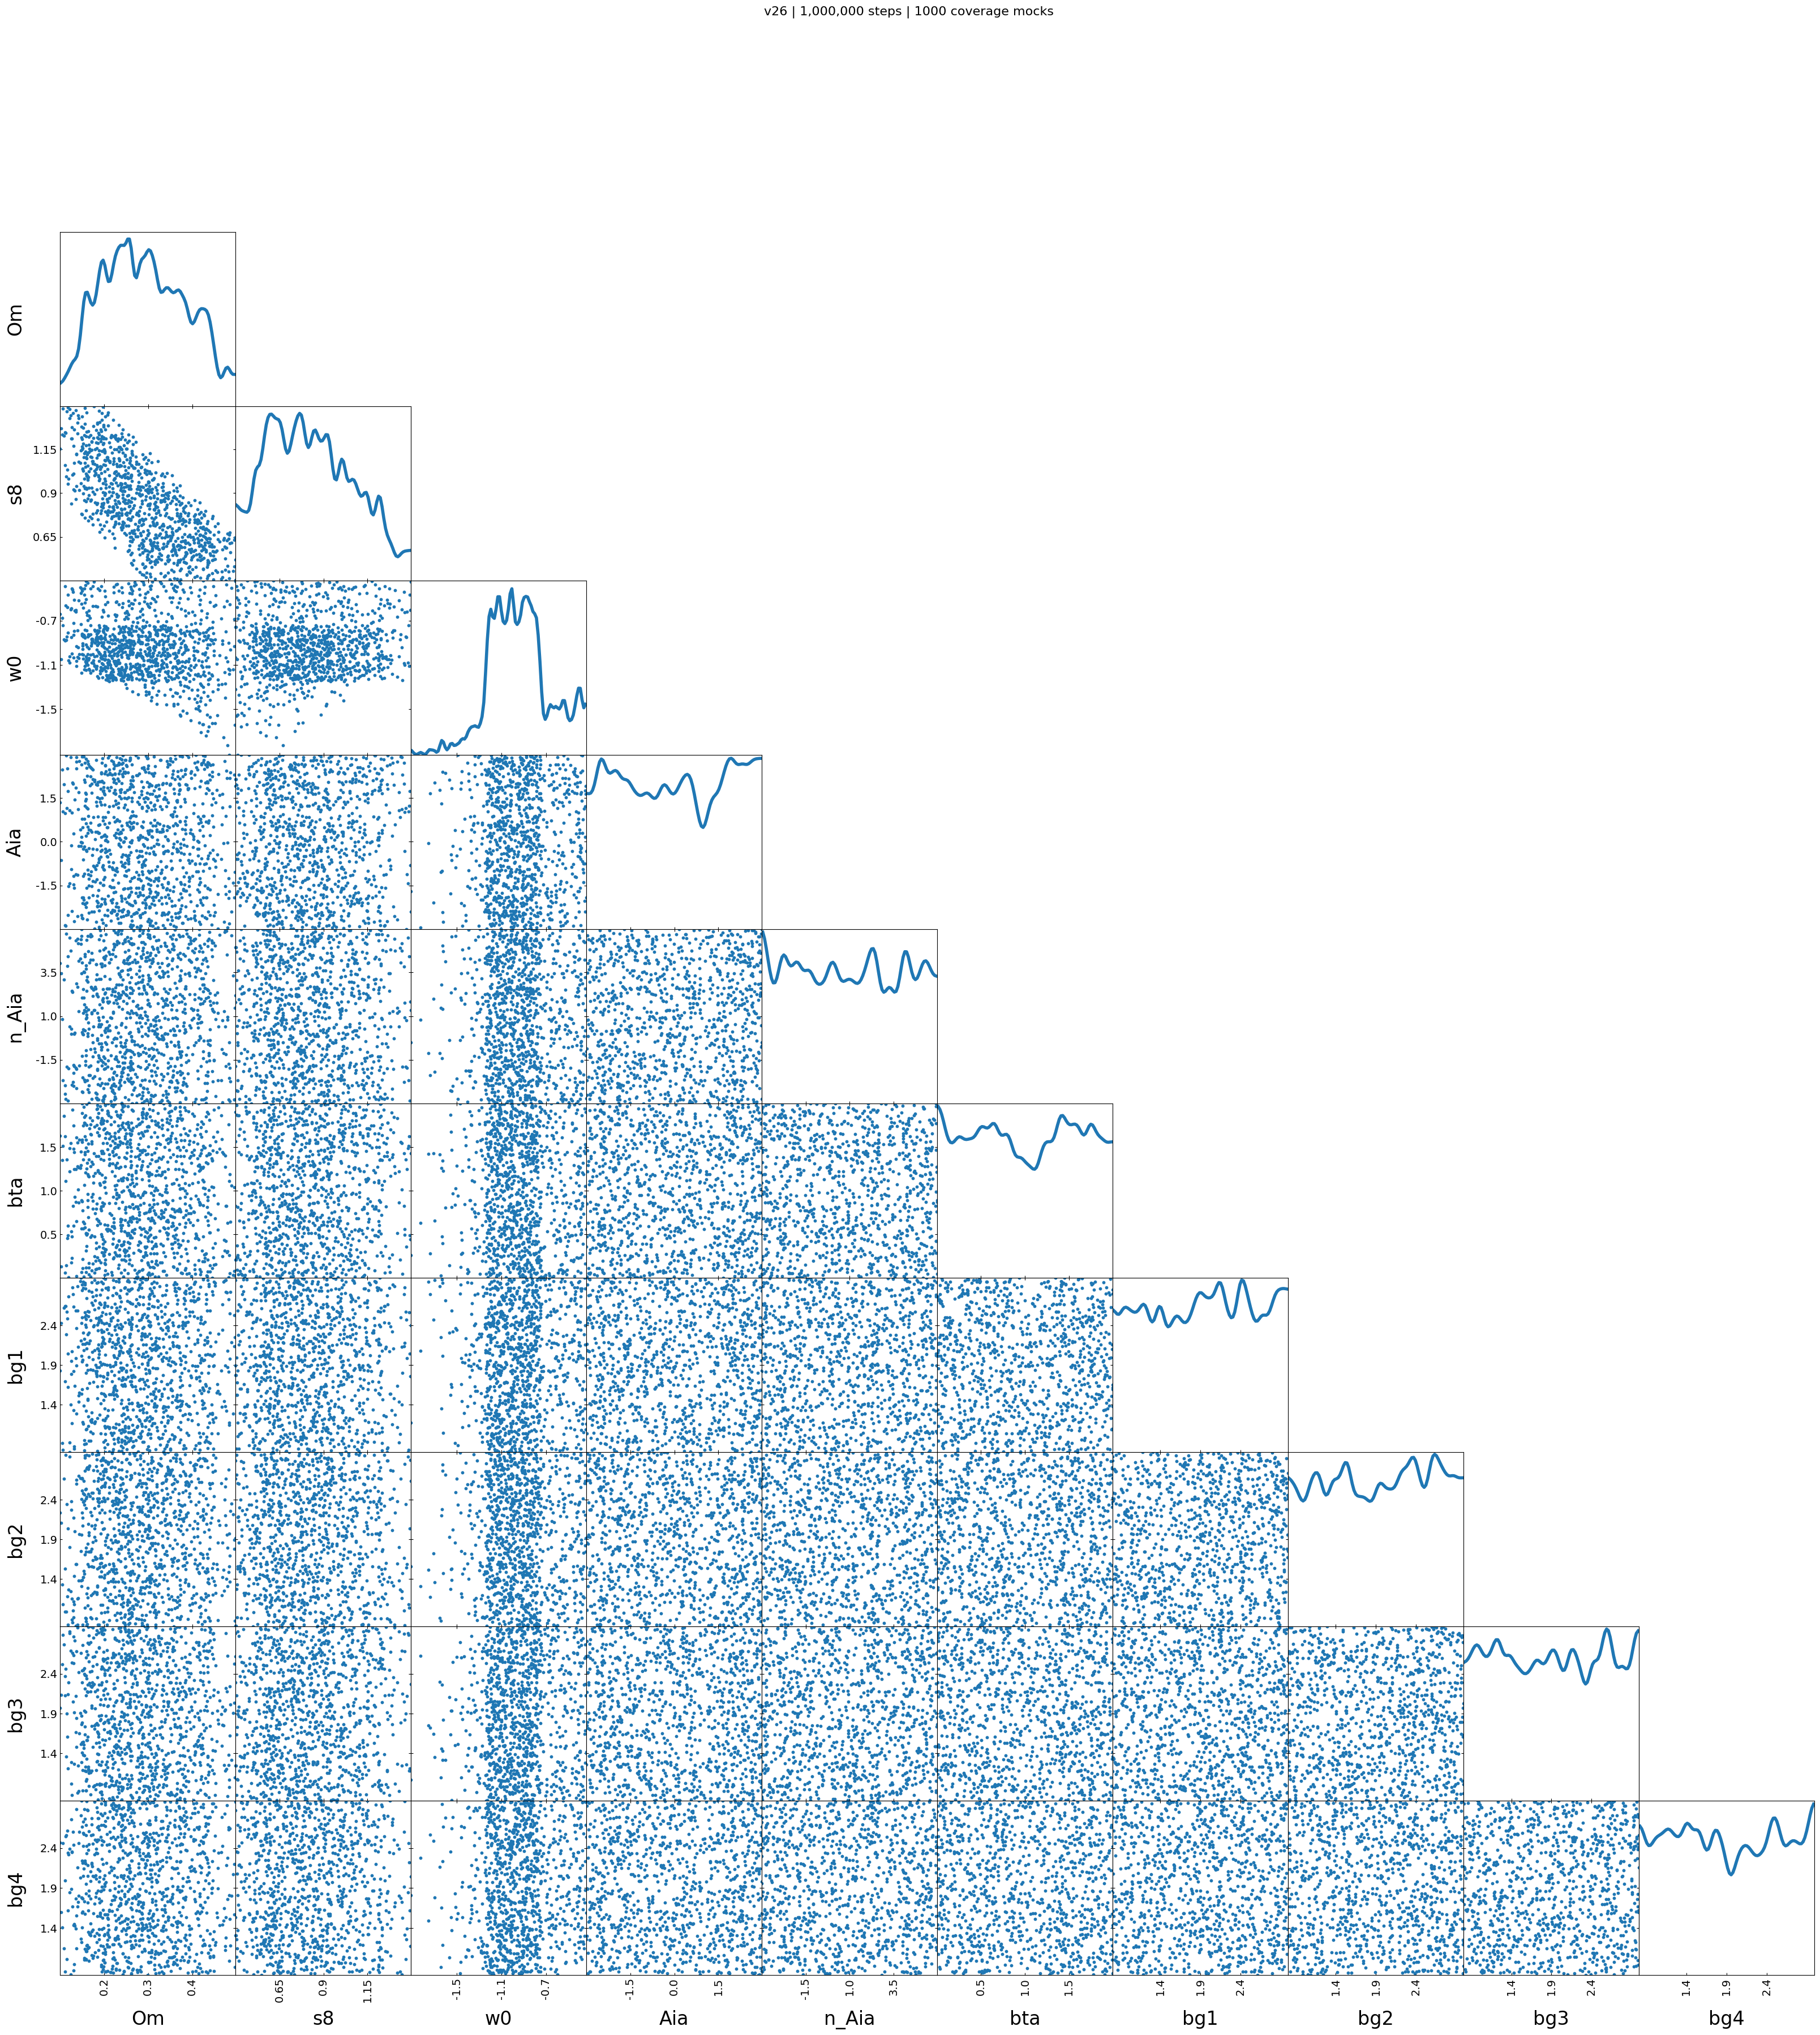

In [12]:
tri = TriangleChain(names=params)
# tri.scatter(grid_cosmos, scatter_kwargs={"s": 3, "marker": "."}, color="lightgray")
tri.scatter(theta_true, scatter_kwargs={"s": 10, "marker": "o"}, color="tab:blue")
tri.fig.suptitle(f"{model_name} | {n_steps:,} steps | {n_obs} coverage mocks", fontsize=16)
plt.show()

In [13]:
theta_true

array([[ 0.3       ,  0.9       , -1.1665    , ...,  2.465184  ,
         2.796318  ,  2.524071  ],
       [ 0.2       ,  1.15      , -0.74975   , ...,  2.0359292 ,
         1.5091858 ,  2.992913  ],
       [ 0.475     ,  0.4625    , -1.2706875 , ...,  2.5599535 ,
         1.9456875 ,  1.171547  ],
       ...,
       [ 0.27466583,  0.92428815, -1.1627927 , ...,  2.9049625 ,
         1.8553804 ,  1.4482132 ],
       [ 0.3555252 ,  0.66159284, -0.8258112 , ...,  1.646406  ,
         2.684428  ,  1.8234473 ],
       [ 0.40865022,  0.66940534, -1.0993034 , ...,  2.5489697 ,
         1.0544229 ,  0.8593435 ]], shape=(1000, 10), dtype=float32)